# ReplaceBG – Carbohydrate Data (HDeviceWizard)

This notebook explores the raw carbohydrate data from the ReplaceBG study to understand its quality and inform extraction decisions. The source is `HDeviceWizard.txt`, which records every pump bolus wizard calculation event.

## 1. Setup & Load

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
import seaborn as sns
from babelbetes.src import drawing,cdf,pandas_helper
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

sys.path.append(os.path.join(os.getcwd(), '..', '..'))

BASE = os.path.join(os.getcwd(), '..', '..', 'data', 'raw', 'REPLACE-BG Dataset-79f6bdc8-3c51-4736-a39f-c4c0f71d45e5', 'Data Tables')
ENROLLMENT_START = datetime(2015, 3, 1)

df_wizard = pd.read_csv(os.path.join(BASE, 'HDeviceWizard.txt'), sep='|', dtype={'PtId': str})
df_wizard = df_wizard.assign(datetime=pd.Timestamp('2025-01-01') + pd.to_timedelta(df_wizard.DeviceDtTmDaysFromEnroll,unit='Days')+pd.to_timedelta(df_wizard.DeviceTm))
df_wizard = df_wizard.rename(columns={'PtId':'PtID'})
df_bolus = pd.read_csv(os.path.join(BASE, 'HDeviceBolus.txt'), sep='|', dtype={'PtID': str})
roster     = pd.read_csv(os.path.join(BASE, 'HPtRoster.txt'),  sep='|', dtype={'PtID': str})

In [7]:
df_cgm_all = pd.read_csv(os.path.join(BASE, 'HDeviceCGM.txt'), sep='|', dtype={'PtID': str})

## 2. Study Design & Timeline

**Source:** `HPtRoster.txt` (enrollment/randomization metadata) and `HDeviceCGM.txt`
(actual device data range inferred from `DeviceDtTmDaysFromEnroll` per patient).

ReplaceBG was a:  
 - randomized trial comparing insulin dosing with CGM only vs. CGM + BGM 
 - in 226 T1D adults. 
 - 2-10 weeks enrollment phase + 26 weeks intervention
 
All timestamps are stored in **days relative to each patient's enrollment
date (Day 0)**, so patients are not calendar-aligned to each other.

| | |
|---|---|
| Total patients | 226 (217 completed, 9 dropped) |
| CGM Only arm | 149 |
| CGM + BGM arm | 77 |
| Randomization | Median day 69 post-enrollment (range 12–144 days) — i.e. ~2-month run-in |
| Core study end | ~Day 252 (tight cluster: 25th–75th pct day 245–259 ≈ 6 months post-randomization) |

**Pre-enrollment pump history:** Many patients uploaded existing device data when they
enrolled. 36 patients have CGM records before day −100; one goes back to day −603.

We want to remove data pre-enrollment!

In [38]:
#treatment groups
print('Study arms (HPtRoster.txt → TrtGroup):')
print(roster.TrtGroup.value_counts().to_dict())

#patient status
print(f'\nPtStatus: {roster.PtStatus.value_counts().to_dict()}')

#Enrollment duration
print('\nEnrollment Duration (2-10 weeks per protocol) (HPtRoster.txt → RandDtDaysAfterEnroll):')
display((roster.RandDtDaysAfterEnroll//7).describe())

Study arms (HPtRoster.txt → TrtGroup):
{'CGM Only': 149, 'CGM+BGM': 77}

PtStatus: {'Completed': 217, 'Dropped': 9}

Enrollment Duration (2-10 weeks per protocol) (HPtRoster.txt → RandDtDaysAfterEnroll):


count    226.000000
mean       7.774336
std        4.025194
min        1.000000
25%        4.000000
50%        9.000000
75%       10.000000
max       20.000000
Name: RandDtDaysAfterEnroll, dtype: float64

In [ ]:
df_bolus = df_bolus.assign(day_after_randomization = df_bolus.DeviceDtTmDaysFromEnroll - roster.set_index('PtID').RandDtDaysAfterEnroll.reindex(df_bolus.PtID).values)
df_wizard = df_wizard.assign(day_after_randomization = df_wizard.DeviceDtTmDaysFromEnroll - roster.set_index('PtID').RandDtDaysAfterEnroll.reindex(df_wizard.PtID).values)
df_cgm_all = df_cgm_all.assign(day_after_randomization = df_cgm_all.DeviceDtTmDaysFromEnroll - roster.set_index('PtID').RandDtDaysAfterEnroll.reindex(df_cgm_all.PtID).values)

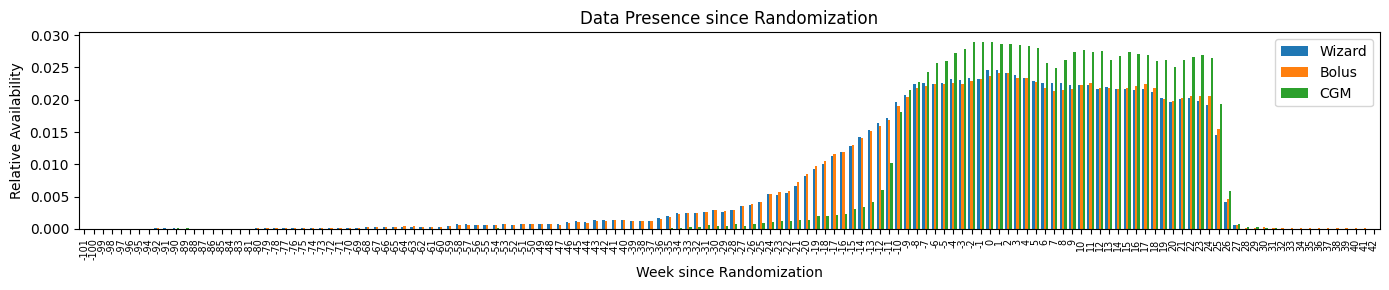

In [40]:
# data availability in days since randomization
f = plt.figure(figsize=(14,3))
ax = plt.gca()
combined = pd.DataFrame({
    'Wizard': (df_wizard['day_after_randomization']//7).value_counts(normalize=True),
    'Bolus':  (df_bolus['day_after_randomization']//7).value_counts(normalize=True),
    'CGM':    (df_cgm_all.sample(frac=.1)['day_after_randomization']//7).value_counts(normalize=True),
}).sort_index()
combined.plot.bar(width=.75,ax=ax)
plt.legend()
plt.xticks(fontsize='x-small')
plt.title('Data Presence since Randomization')
plt.xlabel('Week since Randomization')
plt.ylabel('Relative Availability')
plt.savefig('data_avaialability_replacebg.pdf')
plt.tight_layout()

Text(0.5, 1.0, 'Earliest data point since Enrollment')

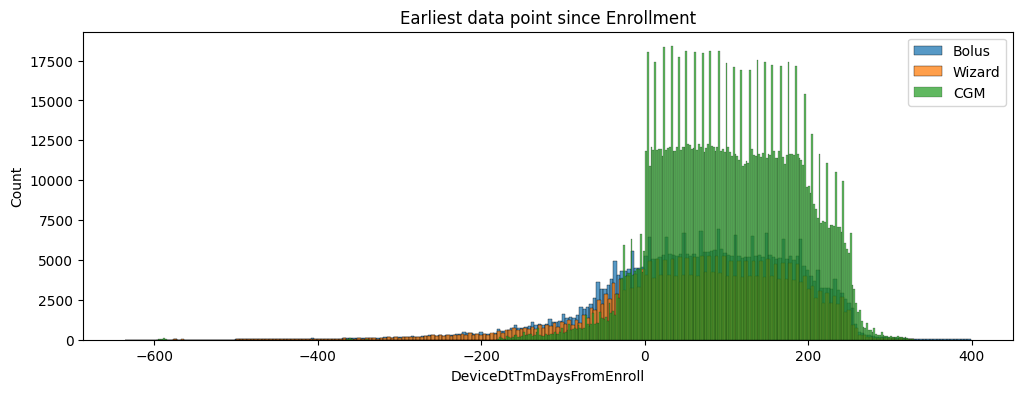

In [52]:
#data before enrollment?
sns.histplot(df_bolus.DeviceDtTmDaysFromEnroll,label='Bolus')
sns.histplot(df_wizard.DeviceDtTmDaysFromEnroll,label='Wizard')
sns.histplot(df_cgm_all.sample(frac=0.1).DeviceDtTmDaysFromEnroll,label='CGM')
plt.legend()
plt.title('Earliest data point since Enrollment')

## **Takeaways:** 
 - Majority of data comes in 10 weekes before randomization. (makes sense)
 - Data stops about 26 weeks after randomization. (makes sense)
 - We should drop patients that dropped out of study
 - A lot of pre enrollment data, which we should remove.
 - We want to keep data from start of enrollment until study end: `DeviceDtTmDaysFromEnroll = [0, RandDtDaysAfterEnroll + 26weeks]`


## 2. What Does a Wizard Entry Represent?

Each row is one pump bolus wizard calculation event — the user opened the wizard on their pump, entered a BG reading and/or carb amount, and the pump calculated an insulin recommendation. Key columns (from glossary):

| Column | Description |
|---|---|
| `CarbInput` | Carbs entered by user. Glossary says "mg" but values (25, 45, …) are clearly **grams** — a known labeling error. |
| `RecommendedCarb` | Insulin **units** recommended to cover those carbs (not carb grams). |
| `RecommendedCorrection` | Insulin units recommended to correct a high BG. |
| `RecommendedNet` | Total insulin recommendation (carbs + correction − IOB). |
| `InsulinCarbRatio` | Grams of carb covered per unit of insulin (the pump's ICR setting). |
| `InsulinOnBoard` | Active insulin remaining from prior boluses (units). |
| `BgInput` | BG value entered into the wizard (mg/dL). |
| `ParentHDeviceBolusID` | Links to the bolus that was actually delivered. |

**NaN CarbInput**: wizard was opened without entering any carb amount (correction-only use).  
**Zero CarbInput**: user explicitly entered 0 g (correction-only, no meal).  
Both should be excluded from meal carb extraction.

In [54]:
print(f'Shape: {df_wizard.shape}')
print(f'Unique patients: {df_wizard.PtID.nunique()}')

print('Null counts per column:')
display(df_wizard.isnull().sum().to_frame('nulls'))

print('\nCarbInput value distribution summary:')
print(f'  NaN: {df_wizard.CarbInput.isna().sum():,}')
print(f'  == 0: {(df_wizard.CarbInput == 0).sum():,}')
print(f'  > 0: {(df_wizard.CarbInput > 0).sum():,}')

Shape: (309507, 21)
Unique patients: 204
Null counts per column:


,nulls
RecID,0
ParentHDeviceUploadsID,0
PtID,0
SiteID,0
DeviceDtTmDaysFromEnroll,0
DeviceTm,0
RecommendedCarb,0
RecommendedCorrection,0
RecommendedNet,0
BgInput,13154



CarbInput value distribution summary:
  NaN: 17,234
  == 0: 79,246
  > 0: 213,027


### Wizard Coverage for Large Boluses & Delivery Verification

**Source:** `HDeviceBolus.txt` (416k rows) cross-referenced with `HDeviceWizard.txt`
via `ParentHDeviceBolusID` (wizard → bolus link) and `HDeviceBolus.RecID` (bolus → wizard link).

Two questions: (1) what fraction of boluses have a wizard carb record?
(2) were those boluses actually delivered?

In [58]:
df_bolus = pd.read_csv(os.path.join(BASE, 'HDeviceBolus.txt'), sep='|', dtype={'PtID': str})

print(f"{df_wizard.ParentHDeviceBolusID.isin(df_bolus.RecID).mean()*100:.2f}% of all wizard boluses link to the parent bolus records")

# Wizard linkage rate by bolus-size bucket
wiz_ids = set(df_wizard.ParentHDeviceBolusID.dropna().astype(int))
df_bolus['has_wizard'] = df_bolus.RecID.isin(wiz_ids)
bins   = [0, 1, 2, 3, 5, 10, 999]
labels = ['0–1', '1–2', '2–3', '3–5', '5–10', '>10']
df_bolus['size_bucket'] = pd.cut(df_bolus.Normal, bins=bins, labels=labels)

summary = df_bolus.groupby('size_bucket', observed=True).agg(
    n_boluses=('Normal', 'count'),
    pct_wizard=('has_wizard', 'mean')
).reset_index()
summary['pct_wizard'] = (summary['pct_wizard'] * 100).round(1)
print('Fraction of boluses generated by the wizard: (HDeviceBolus.txt → Normal):')
display(summary)
print(f'\nOverall, {df_bolus.has_wizard.mean():.1%} of all boluses, '
      f'{df_bolus[df_bolus.Normal>3].has_wizard.mean():.1%} of boluses >3 U, were generated by a bolus wizard')
print()

# Delivery completeness via ExpectedNormal
# ExpectedNormal is ONLY populated when a bolus was interrupted mid-delivery.
# When ExpectedNormal is NaN, the bolus was fully delivered (Normal = delivered amount).
both = df_bolus[df_bolus.Normal.notna() & df_bolus.ExpectedNormal.notna()].copy()
interrupted = both[both.Normal < both.ExpectedNormal - 0.001]
frac = interrupted.Normal / interrupted.ExpectedNormal
print(f'Boluses with ExpectedNormal populated (HDeviceBolus.txt → ExpectedNormal):')
print(f'  {len(both):,} / {len(df_bolus):,} ({len(both)/len(df_bolus):.2%})')
print(f'  → ExpectedNormal is only set when delivery was interrupted; NaN = fully delivered')
print(f'  Of those, interrupted (Normal < ExpectedNormal): {len(interrupted):,} ({len(interrupted)/len(both):.1%})')
print(f'  Median Fraction of planned bolus delivered when interrupted: {frac.median():.0%}')
print()

wiz_interrupted = df_wizard[
    df_wizard.ParentHDeviceBolusID.notna() &
    df_wizard.ParentHDeviceBolusID.astype('Int64').isin(set(interrupted.RecID))
]
print(f'Wizard carb entries linked to an interrupted bolus: {len(wiz_interrupted):,} '
      f'/ {df_wizard.CarbInput.gt(0).sum():,} ({len(wiz_interrupted)/df_wizard.CarbInput.gt(0).sum():.1%})')
print(f'Wizard carb entries with no ParentHDeviceBolusID: {df_wizard.ParentHDeviceBolusID.isna().sum()}')
print()
print('Conclusion: CarbInput represents the intended meal regardless of delivery status.')
print('~1.1% of entries had partial insulin coverage; 49 had no linked bolus at all.')

99.98% of all wizard boluses link to the parent bolus records
Fraction of boluses generated by the wizard: (HDeviceBolus.txt → Normal):


,size_bucket,n_boluses,pct_wizard
0,0–1,77141,65.1
1,1–2,89066,72.1
2,2–3,70328,76.0
3,3–5,90251,79.1
4,5–10,67690,78.2
5,>10,16465,83.9



Overall, 74.3% of all boluses, 79.2% of boluses >3 U, were generated by a bolus wizard

Boluses with ExpectedNormal populated (HDeviceBolus.txt → ExpectedNormal):
  4,687 / 416,599 (1.13%)
  → ExpectedNormal is only set when delivery was interrupted; NaN = fully delivered
  Of those, interrupted (Normal < ExpectedNormal): 4,674 (99.7%)
  Median Fraction of planned bolus delivered when interrupted: 39%

Wizard carb entries linked to an interrupted bolus: 3,355 / 213,027 (1.6%)
Wizard carb entries with no ParentHDeviceBolusID: 65

Conclusion: CarbInput represents the intended meal regardless of delivery status.
~1.1% of entries had partial insulin coverage; 49 had no linked bolus at all.


## **Takeaways**
 - 204/226 patients in wizard. Unclear why they are missing yet.
 - All Wizard boluses are linked to the Bolus File >99.99%
 - Majority Boluses are calculated using the Wizard
 - Only 1.6% of carb calculated boluses are interrupted.
  - We assume these carbs were eaten!

## 11. Pump Models & Data Source Consistency

**Source:** `HDeviceUploads.txt` (1,740 insulin-pump upload records across 224 patients),
cross-referenced with `HDeviceWizard.txt` (all 309,507 wizard records carry `DataSource = Tidepool`).

Key question: is the bolus wizard available for all patients, or does it depend on the pump or upload platform?

In [81]:
df_uploads = pd.read_csv(os.path.join(BASE, 'HDeviceUploads.txt'), sep='|', dtype={'PtId': str})
pumps = df_uploads[df_uploads.DeviceType.str.contains('insulin-pump', na=False)].copy()

print('Number of Patients per Data Source (some overlap):')
display(df_uploads.groupby('DataSource').PtId.nunique())

#Wizard by Data source
df_wiz_merged = df_wizard.merge(
    df_uploads[['RecID', 'DataSource', 'DeviceModel']].rename(columns={'RecID': 'ParentHDeviceUploadsID'}),
    on='ParentHDeviceUploadsID', how='left'
)

diasend_pts  = set(df_wiz_merged[df_wiz_merged.DataSource == 'Diasend'].PtID.unique())
tidepool_pts = set(df_wiz_merged[df_wiz_merged.DataSource == 'Tidepool'].PtID.unique())
print(f'Patients with Diasend wizard uploads: {len(diasend_pts)}')
print(f'Patients with Tidepool wizard uploads: {len(tidepool_pts)}')


print(f'Implication: We have {roster.PtID.nunique()} patients overall, {df_wizard.PtID.nunique()} have wizard data.')

Number of Patients per Data Source (some overlap):


DataSource
Diasend        18
Glucofacts    181
Studio          6
Tidepool      226
Name: PtId, dtype: int64

Patients with Diasend wizard uploads: 0
Patients with Tidepool wizard uploads: 204
Implication: We have 226 patients overall, 204 have wizard data.


In [113]:
missing_patients = set(roster.PtID.unique())-set(df_wizard.PtID.unique())
insulin_sources = df_uploads[
    df_uploads.PtId.isin(missing_patients) & df_uploads.DeviceType.str.contains('insulin')
].groupby("PtId").DataSource.agg('unique')
display(insulin_sources)
print(f"From the {len(missing_patients)} missing patients,  {len(insulin_sources)} we have uploaded insulin data, most of it comes from Diasend")

PtId
113     [Diasend]
136    [Tidepool]
184     [Diasend]
197    [Tidepool]
210     [Diasend]
217     [Diasend]
22      [Diasend]
226     [Diasend]
236     [Diasend]
252     [Diasend]
257     [Diasend]
260     [Diasend]
265     [Diasend]
267     [Diasend]
276    [Tidepool]
47      [Diasend]
73     [Tidepool]
81      [Diasend]
89      [Diasend]
9       [Diasend]
Name: DataSource, dtype: object

From the 22 missing patients,  20 we have uploaded insulin data, most of it comes from Diasend


The majority of data is present, 22 patients from the record have no wizard data. Majority because Diasend doesn't provide any data here. 

## 3. Consistency Check: CarbInput Units

Verify that `CarbInput / InsulinCarbRatio ≈ RecommendedCarb` (accounting for IOB adjustment), which confirms CarbInput is in **grams**, not mg.

As we see, the calculation is correct with a few exceptions. However, these come from only 3 patients.


Residual stats (RecommendedCarb − CarbInput/ICR):
count    213027.000
mean          0.075
std           0.991
min         -12.000
25%          -0.036
50%          -0.004
75%           0.000
max          19.787
Name: residual, dtype: float64


,CarbInput,InsulinCarbRatio,expected_carb_rec,RecommendedCarb,RecommendedNet,BgInput,InsulinSensitivity,RecommendedCorrection,InsulinOnBoard,BgTargetTarget
69542,1.0,20.4,0.049020,1.3,1.3,0.00,2.33,0.0,0.0,NaN
223666,6.0,22.5,0.266667,9.0,11.4,11.60,2.00,2.4,0.0,NaN
229309,5.5,37.5,0.146667,13.7,15.9,9.16,1.11,2.2,0.0,NaN
69879,2.0,18.8,0.106383,2.5,2.5,0.00,2.33,0.0,0.0,NaN
229335,5.5,37.5,0.146667,13.7,17.5,10.88,1.11,3.8,0.0,NaN


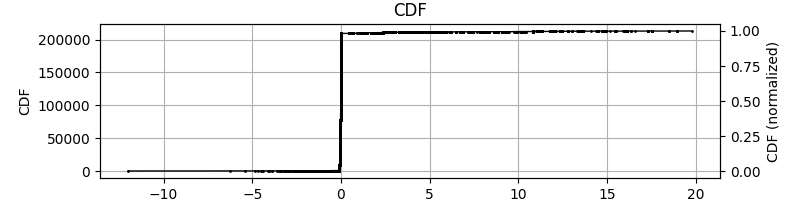

In [144]:
# Only rows with carbs > 0 and valid ICR
df_check = df_wizard[(df_wizard.CarbInput > 0) & (df_wizard.InsulinCarbRatio > 0)].copy()

# Expected carb recommendation without IOB
df_check['expected_carb_rec'] = df_check.CarbInput / df_check.InsulinCarbRatio

# Residual: actual vs expected (IOB may reduce the net recommendation)
df_check['residual'] = df_check.RecommendedCarb - df_check.expected_carb_rec

print(f'\nResidual stats (RecommendedCarb − CarbInput/ICR):')
print(df_check.residual.describe().round(3))

display(df_check[df_check.residual.abs()>1].sample(5)[['CarbInput','InsulinCarbRatio','expected_carb_rec','RecommendedCarb','RecommendedNet','BgInput','InsulinSensitivity','RecommendedCorrection','InsulinOnBoard','BgTargetTarget']])

from babelbetes.src import cdf
cdf.plot_cdf(df_check.residual)


In [145]:
#patients with average large deviations
cols = ['InsulinCarbRatio','CarbInput','RecommendedCarb','expected_carb_rec','BgInput','InsulinSensitivity','RecommendedCorrection','InsulinOnBoard','RecommendedNet']
display(df_check.groupby('PtID').residual.agg(lambda x: x.abs().mean()).sort_values().tail(5))

print(f'Example Outliers:')
outliers = ['244','277','288']
display(df_check.query("PtID in @outliers").sample(5)[cols])

#These are clearly wrong: we drop these patients
df_check = df_check.query("PtID not in @outliers")

PtID
48      0.205805
246     0.207498
244     1.937698
277     8.144730
288    10.069662
Name: residual, dtype: float64

Example Outliers:


,InsulinCarbRatio,CarbInput,RecommendedCarb,expected_carb_rec,BgInput,InsulinSensitivity,RecommendedCorrection,InsulinOnBoard,RecommendedNet
230153,37.5,5.0,12.5,0.133333,12.82,1.11,5.5,0.0,18.0
70481,21.8,3.0,4.3,0.137615,0.00,2.33,0.0,0.0,4.3
70921,18.8,1.5,1.8,0.079787,0.00,2.33,0.0,0.0,1.8
223406,37.5,1.0,2.5,0.026667,13.93,2.00,3.6,1.0,5.1
70883,18.8,1.5,1.8,0.079787,0.00,2.33,0.0,0.0,1.8


In [146]:
#examples of large deviations
df_check[df_check.residual.abs()>2].sample(5)[cols]

,InsulinCarbRatio,CarbInput,RecommendedCarb,expected_carb_rec,BgInput,InsulinSensitivity,RecommendedCorrection,InsulinOnBoard,RecommendedNet
258736,5.0,24.0,2.29,4.8,5.33,2.22,0.0,2.41,2.29
137209,10.0,370.0,25.00,37.0,0.00,1.22,0.0,0.00,25.00
137311,10.0,74.0,2.74,7.4,2.11,1.22,0.0,1.84,2.74
136977,10.0,75.0,5.22,7.5,3.16,1.22,0.0,0.33,5.22
136962,10.0,63.0,3.80,6.3,2.50,1.22,0.0,0.00,3.80


The remaining outliers are likely a result of different BC algorithsm:
Reducing Carb Bolus by IOB
Limiting By Max Bolus Size
Reducing Carb bolus because of low BG

We keep them.

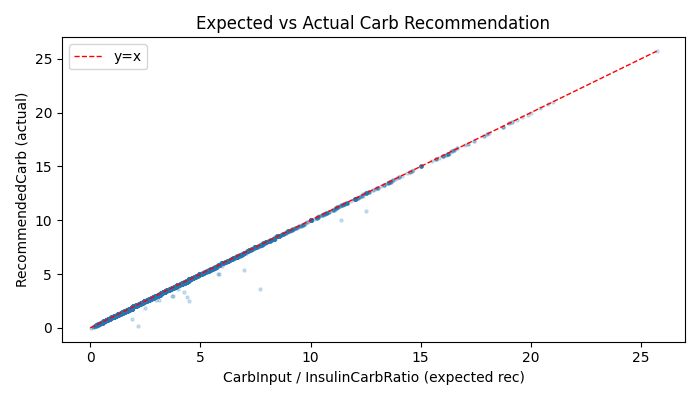

Entries with |residual| < 0.1 units: 99.7%  → CarbInput is in grams ✓


In [147]:
fig, ax = plt.subplots(1, 1, figsize=(7,4))
axes = [ax]
# Scatter: actual vs expected
sample = df_check.sample(min(5000, len(df_check)), random_state=42)
axes[0].scatter(sample.expected_carb_rec, sample.RecommendedCarb, alpha=0.2, s=5)
lim = max(sample.expected_carb_rec.max(), sample.RecommendedCarb.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1, label='y=x')
axes[0].set_xlabel('CarbInput / InsulinCarbRatio (expected rec)')
axes[0].set_ylabel('RecommendedCarb (actual)')
axes[0].set_title('Expected vs Actual Carb Recommendation')
axes[0].legend()

plt.tight_layout()
plt.show()

agreement = (df_check.residual.abs() < 0.1).mean()
print(f'Entries with |residual| < 0.1 units: {agreement:.1%}  → CarbInput is in grams ✓')

## Duplicates

In [153]:
df_carbs = df_wizard[df_wizard.CarbInput > 0].copy()

exact_dups = df_carbs.duplicated(subset=['PtID', 'DeviceDtTmDaysFromEnroll', 'DeviceTm', 'CarbInput']).sum()
temporal_dups = df_carbs.duplicated(subset=['PtID', 'DeviceDtTmDaysFromEnroll', 'DeviceTm']).sum()

print(f'Entries with CarbInput > 0: {len(df_carbs):,}')
print(f'Exact duplicates (patient + time + carbs): {exact_dups:,}  ({exact_dups/len(df_carbs):.2%})')
print(f'Temporal duplicates (patient + time only): {temporal_dups:,}  ({temporal_dups/len(df_carbs):.2%})')
print()
if exact_dups == temporal_dups:
    print('Exact dups == temporal dups → all temporal duplicates share the same CarbInput value.')
    print('Resolution: drop_duplicates on [PtID, DeviceDtTmDaysFromEnroll, DeviceTm, CarbInput] is sufficient.')
else:
    # Show examples where same time but different CarbInput
    temporal_only = df_carbs[df_carbs.duplicated(subset=['PtID', 'DeviceDtTmDaysFromEnroll', 'DeviceTm'], keep=False)]
    exact_mask = df_carbs.duplicated(subset=['PtId', 'DeviceDtTmDaysFromEnroll', 'DeviceTm', 'CarbInput'], keep=False)
    conflicting = temporal_only[~exact_mask]
    print(f'WARNING: {temporal_dups - exact_dups} temporal dups have DIFFERING CarbInput values:')
    display(conflicting.head(10))

Entries with CarbInput > 0: 213,027
Exact duplicates (patient + time + carbs): 2,004  (0.94%)
Temporal duplicates (patient + time only): 2,004  (0.94%)

Exact dups == temporal dups → all temporal duplicates share the same CarbInput value.
Resolution: drop_duplicates on [PtID, DeviceDtTmDaysFromEnroll, DeviceTm, CarbInput] is sufficient.


## Value Distribution

We see some very large boluses. However, the numbers are really small. The calcualted value appear to make sense. The actual delivered boluses differ. They are likely capped by maximum delivery or interrupted by the user.

Entries after dedup: 211,023

CarbInput stats (grams):
count    211023.0
mean         38.6
std          25.1
min           0.5
25%          20.0
50%          33.0
75%          50.0
max         370.0
Name: CarbInput, dtype: float64


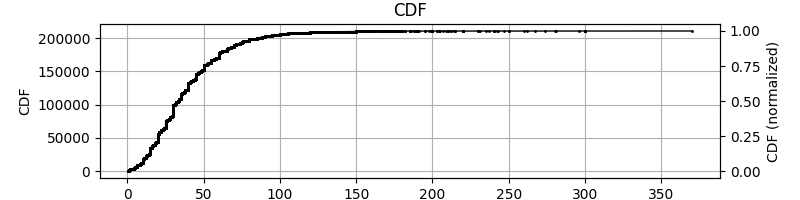

In [191]:
df_dedup = df_carbs.drop_duplicates(subset=['PtID', 'DeviceDtTmDaysFromEnroll', 'DeviceTm', 'CarbInput'])

carb_vals = df_dedup.CarbInput
cdf.plot_cdf(carb_vals)

print(f'Entries after dedup: {len(df_dedup):,}')
print(f'\nCarbInput stats (grams):')
print(carb_vals.describe().round(1))
plt.show()

# display(carb_vals.groupby(pd.cut(carb_vals,[0,50,100,200,400])).size())
# largest_carbs = df_wizard.loc[df_wizard.CarbInput.dropna().sort_values().tail(5).index]
# display(largest_carbs[['PtID','datetime','CarbInput','InsulinCarbRatio','RecommendedCarb']])

# ptids_largest_boluses = largest_carbs.PtID.unique()
# print('Boluses for patients with largest boluses:..')
# df_carbs.query("PtID in @ptids_largest_boluses").RecommendedCarb.describe()

In [192]:
# display(largest_carbs[['ParentHDeviceBolusID','RecommendedNet']].merge(df_bolus,left_on='ParentHDeviceBolusID',right_on='RecID')[['RecommendedNet','ExpectedNormal','Normal','Extended']])

Yes, these boluses are actually linked to boluses but they differ in size. 
 - Some of these were likely capped by maximum bolus. Some were interrupted.

Entries with CarbInput > 200 g (53 rows):


,RecID,ParentHDeviceBolusID,CarbInput,InsulinCarbRatio,RecommendedCarb,RecommendedNet,ExpectedNormal,Normal,Extended,deviation
0,361310,361310.0,370.0,10.0,25.00,25.00,NaN,25.00,NaN,0.00
1,393904,393904.0,300.0,6.0,50.00,50.40,NaN,15.00,NaN,-35.40
2,297140,297140.0,300.0,6.0,50.00,50.00,14.9,0.30,NaN,-49.70
3,67319,67319.0,300.0,12.0,25.00,25.00,NaN,12.00,NaN,-13.00
4,194146,194146.0,300.0,15.0,20.00,19.90,10.0,6.40,NaN,-13.50
5,68479,68479.0,300.0,12.0,25.00,25.00,NaN,10.00,NaN,-15.00
6,44866,44866.0,296.0,13.0,22.70,22.70,18.5,0.45,NaN,-22.25
7,362426,362426.0,281.0,10.0,25.00,25.00,NaN,25.00,NaN,0.00
8,362050,362050.0,280.0,10.0,22.59,25.00,NaN,25.00,NaN,0.00
9,101366,101366.0,274.0,9.0,30.40,30.40,NaN,10.00,NaN,-20.40


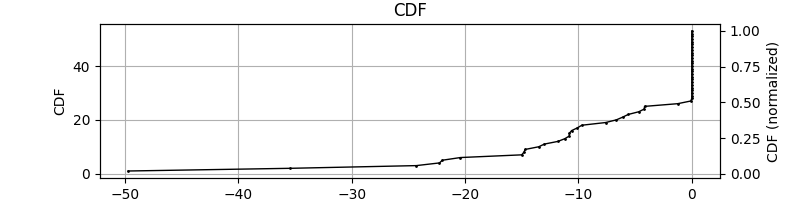

In [201]:
# Inspect high-carb outliers
outliers = df_dedup[df_dedup.CarbInput > 200].sort_values('CarbInput', ascending=False)
print(f'Entries with CarbInput > 200 g ({len(outliers)} rows):')
temp = outliers[['ParentHDeviceBolusID','CarbInput','InsulinCarbRatio','RecommendedCarb','RecommendedNet']].merge(df_bolus,left_on='ParentHDeviceBolusID',right_on='RecID')
temp = temp.assign(deviation = temp.Normal-temp.RecommendedNet)
display(temp[['RecID','ParentHDeviceBolusID', 'CarbInput', 'InsulinCarbRatio', 'RecommendedCarb', 'RecommendedNet','ExpectedNormal','Normal','Extended','deviation']])

cdf.plot_cdf(temp.deviation)

Actually, about 50% of these boluses were delviered all the way. The rest is likely interrupted or clipped by maximum pump setting.

## Daily Sums

The numbers look reasonable and suggest that complete carb data is available.

In [203]:
# Reconstruct datetime for daily aggregation
df_dedup = df_dedup.copy()
df_dedup['datetime'] = (ENROLLMENT_START
                        + pd.to_timedelta(df_dedup.DeviceDtTmDaysFromEnroll, unit='D')
                        + pd.to_timedelta(df_dedup.DeviceTm))
df_dedup['date'] = df_dedup.datetime.dt.date

daily = df_dedup.groupby(['PtID', 'date']).agg(
    daily_carbs=('CarbInput', 'sum'),
    meal_count=('CarbInput', 'count')
).reset_index()

print('Daily carb totals per patient-day:')
print(daily.daily_carbs.describe().round(1))
print(f'\nMedian meals/day: {daily.meal_count.median():.1f}')
print(f'Mean daily carbs: {daily.daily_carbs.mean():.0f} g  (expected ~150-200 g for T1D)')

Daily carb totals per patient-day:
count    57027.0
mean       143.0
std         82.9
min          0.5
25%         86.0
50%        132.0
75%        187.0
max       1170.0
Name: daily_carbs, dtype: float64

Median meals/day: 3.0
Mean daily carbs: 143 g  (expected ~150-200 g for T1D)


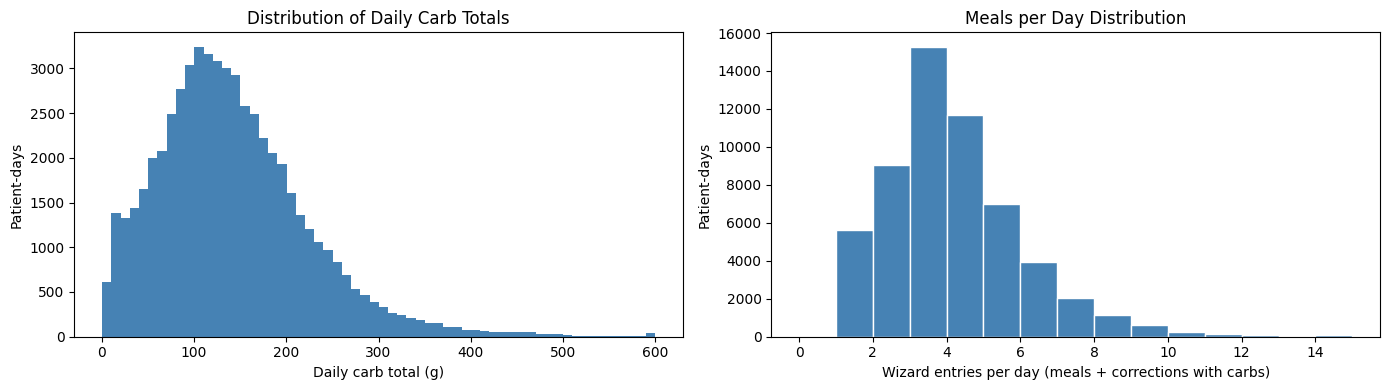

In [206]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(daily.daily_carbs.clip(0, 600), bins=60, edgecolor='none', color='steelblue')
axes[0].set_xlabel('Daily carb total (g)')
axes[0].set_ylabel('Patient-days')
axes[0].set_title('Distribution of Daily Carb Totals')

axes[1].hist(daily.meal_count.clip(0, 15), bins=range(0, 16), edgecolor='white', color='steelblue')
axes[1].set_xlabel('Wizard entries per day (meals + corrections with carbs)')
axes[1].set_ylabel('Patient-days')
axes[1].set_title('Meals per Day Distribution')

plt.tight_layout()
plt.show()

## Daily distirbution

<Axes: xlabel='datetime'>

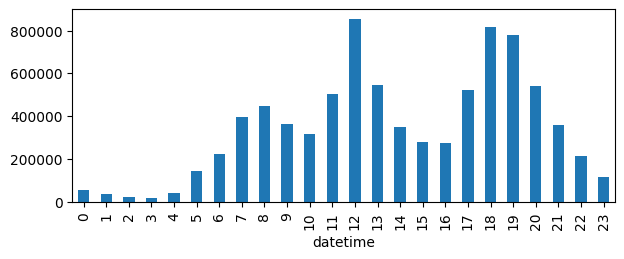

In [207]:
f = plt.figure(figsize=(7,2.5))
ax= plt.gca()
df_carbs.groupby(df_carbs.datetime.dt.hour).CarbInput.sum().plot.bar()

As expected: breakfast, lunch, dinner.

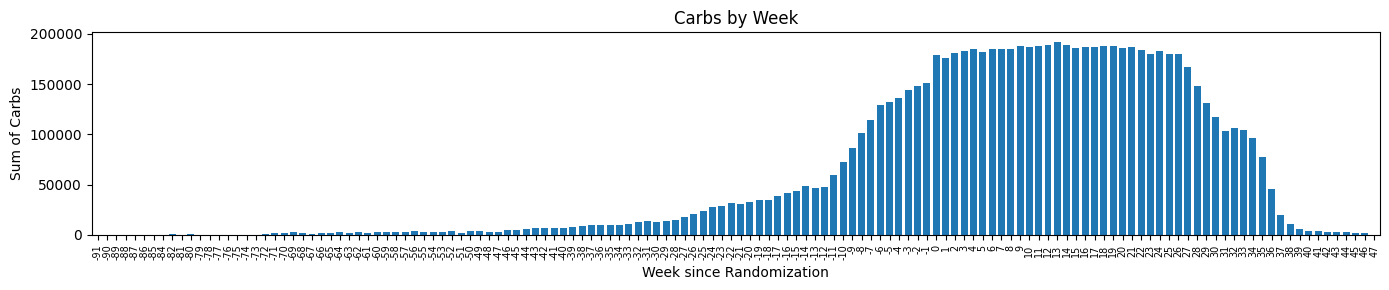

In [219]:
# carb data 
f = plt.figure(figsize=(14,3))
ax = plt.gca()
df_wizard.groupby(df_wizard.DeviceDtTmDaysFromEnroll//7).CarbInput.sum().plot.bar(width=.75,ax=ax)
plt.xticks(fontsize='x-small')
plt.title('Carbs by Week')
plt.xlabel('Week since Randomization')
plt.ylabel('Sum of Carbs')
plt.savefig('data_avaialability_replacebg.pdf')
plt.tight_layout()

Again, we see a lot of data available before enrollment. Likely for those that brought their own device. 

## Summary & Extraction Decisions

### Data source
Carbohydrate data comes exclusively from `HDeviceWizard.txt` (bolus wizard calculation events). There is no separate meal log.

### Coverage
- 204 / 226 patients have wizard data. Most of these were uploaded via **Diasend**, which does not export wizard records. These patients cannot contribute carb data.
- 3 patients (244, 277, 288) have systematically inconsistent `CarbInput / InsulinCarbRatio ≠ RecommendedCarb` ratios and should be **excluded**.

### Units
`CarbInput` is in **grams** (the glossary label "mg" is a known documentation error, confirmed by the `CarbInput / ICR ≈ RecommendedCarb` identity).

### Filtering rules
| Step | Condition | Rows removed |
|---|---|---|
| Correction-only wizard uses | `CarbInput` is NaN or 0 | 96,480 (31%) |
| Pre-enrollment data | `DeviceDtTmDaysFromEnroll < 0` | variable per patient |
| Post-study data | `day_after_randomization > 26 × 7` | variable per patient |
| ICR-inconsistent patients | PtID in {244, 277, 288} | ~3 patients |
| Exact duplicates | same PtID + timestamp + CarbInput | ~2,004 (0.94%) |

### Quality
- **99.98 %** of wizard entries link back to a delivered bolus.
- Only **1.6 %** of carb-wizard entries are linked to an interrupted bolus; we keep these (carbs were likely consumed regardless).
- Daily totals (mean 143 g/day, median 3 meals/day) are clinically plausible for T1D adults.
- Temporal pattern matches expected meal times (breakfast / lunch / dinner).

### Extraction logic
```python
# keep only meal carb entries, post-enrollment, deduplicated
df = df_wizard[df_wizard.CarbInput > 0].copy()
df = df[df.DeviceDtTmDaysFromEnroll >= 0]
df = df[df.day_after_randomization <= 26 * 7]
df = df[~df.PtID.isin(['244', '277', '288'])]
df = df.drop_duplicates(subset=['PtID', 'DeviceDtTmDaysFromEnroll', 'DeviceTm', 'CarbInput'])
```